# import

In [1]:
# Suppression des warnings FutureWarning
import warnings  # Gère les warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import os # Manipulation des données et répertoires
import shutil # Mélanger les données
import zipfile  # Manipulation des archives ZIP
import numpy as np  # Calcul scientifique et manipulation de matrices
import pandas as pd # Manipulation de données tabulaires

# Librairie d'affichage
import matplotlib.pyplot as plt # Visualisation de données
from matplotlib.offsetbox import (OffsetImage,
                                  AnnotationBbox) # Visualisation de données
from sklearn.manifold import TSNE  # Visualisation dimension réduite
import seaborn as sns # Visualisation de données
from matplotlib import cm  # Colormaps pour les visualisations 3D ou KDE
from mpl_toolkits.mplot3d import Axes3D  # Support pour les graphiques 3D
from scipy.stats import gaussian_kde  # Estimation de densité par noyau (KDE)
from PIL import Image  # Chargement et traitement d'images (format standard)

# TensorFlow et Keras
import tensorflow as tf  # API principale de TensorFlow
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Générateur
from tensorflow.keras.layers import (Layer, Input, Conv2D, Flatten,
                                    Dense, Lambda, LeakyReLU,
                                    Conv2DTranspose, Reshape,
                                    BatchNormalization,
                                    Cropping2D) # Différentes couches
from tensorflow.keras.models import Model # Définition/chargement des modèles
from tensorflow.keras import backend as K # Import opérations bas niveau
from tensorflow.keras.callbacks import (ModelCheckpoint,
                                        EarlyStopping) # Gestion des callbacks
from tensorflow.keras.preprocessing.image import (array_to_img,
                                                  load_img,
                              img_to_array) # Manipulation d'images avec Keras
from tensorflow.keras.utils import register_keras_serializable # Sérialisation
from tensorflow.keras.models import load_model  # Chargement modèle

# Scikit learn
from sklearn.cluster import KMeans # Pour calculer les clusters
from sklearn.metrics import silhouette_score # Pour calcul nombre de clusters

# dataset

In [26]:
# Nom local de l'archive et URL source
zip_file = "Fruits360Small.zip"
zip_url = "https://www.lirmm.fr/~poncelet/Ressources/Fruits360Small.zip"

# Répertoire cible après extraction
src_dir = "Fruits360Small"

# Vérifie s'il y a au moins une image .jpg dans un des sous-dossiers
def fruit_already_present():
    if not os.path.exists(src_dir):
        return False
    for root, dirs, files in os.walk(src_dir):
        if any(f.lower().endswith(".jpg") for f in files):
            return True
    return False

# Téléchargement et extraction seulement si nécessaire
if not fruit_already_present():
    print("Aucune image trouvée dans Fruits360Small. Extraction en cours...")

    # Télécharger si l'archive n'est pas déjà présente
    if not os.path.exists(zip_file):
        print(f"Téléchargement de {zip_file}...")
        !Powershell.exe -Command ((new-object System.Net.WebClient).DownloadFile('{zip_url}','{zip_file}'))
    else:
        print(f"{zip_file} déjà présent, téléchargement ignoré.")

    # Extraction (en évitant les dossiers système)
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        for member in zip_ref.namelist():
            if not member.startswith("__MACOSX") and not member.endswith("/"):
                zip_ref.extract(member, ".")

    print("Archive extraite avec succès.")
    os.remove(zip_file)
else:
    print("Le dossier Fruits360Small existe déjà et contient des images.")

Le dossier Fruits360Small existe déjà et contient des images.


In [27]:
# Configuration générale pour les données
image_height=  100  # Hauteur des images
image_width = 100   # Largeur des images
image_size = (image_height, image_width, 3)  # Dimensions des images

# Pour les modèles
batch_size = 64     # Taille des lots
latent_dim = 16     # Dimension de l'espace latent pour le VAE

model_dir = "../models/"
os.makedirs(model_dir, exist_ok=True)

# Les images sont toutes dans Fruits360Small/train ;
# la classe est donnée par la première lettre du nom du fichier.
dataset_root = "./Fruits360Small"
dataset_configs = {
    "tomates_seules": {"path": dataset_root, "labels": ("t",)},
    "tomates_bananes": {"path": dataset_root, "labels": ("t", "b")},
    "tomates_poires_bananes": {"path": dataset_root, "labels": ("t", "p", "b")}
}

In [28]:
def extract_image_labels(dataset_name, dataset_dir, allowed_labels, save_dir):
    """
    Extrait les noms de fichiers et labels (1ère lettre du nom)
    depuis dataset_dir/train/ puis les sauvegarde dans un fichier .npz.


    Args:
        dataset_name : str, nom du dataset (pour nommer le fichier .npz)
        dataset_dir  : str, chemin vers le dataset contenant le dossier 'train/'
        allowed_labels : iterable[str], préfixes de classes à conserver
        save_dir     : str, chemin où sauvegarder le fichier .npz
    """
    train_dir = os.path.join(dataset_dir, "train")
    allowed_labels = set(allowed_labels)

    filenames = []
    labels = []

    for f in os.listdir(train_dir):
        if not f.lower().endswith(".jpg"):
            continue

        label = f[0].lower()
        if label not in allowed_labels:
            continue

        filenames.append(os.path.join("train", f))
        labels.append(label)

    filenames = np.array(sorted(filenames))
    labels = np.array([os.path.basename(path)[0].lower() for path in filenames])

    save_path = os.path.join(save_dir, f"{dataset_name}_image_labels.npz")
    np.savez(save_path, filenames=filenames, labels=labels)


for dataset_name, dataset_config in dataset_configs.items():
    extract_image_labels(
        dataset_name=dataset_name,
        dataset_dir=dataset_config["path"],
        allowed_labels=dataset_config["labels"],
        save_dir=model_dir
    )

# models

In [29]:
# Fonction d'échantillonnage
@register_keras_serializable(package='Custom', name='sampling')
def sampling(args):
    mean_mu, log_var = args
    epsilon = K.random_normal(shape=K.shape(mean_mu), mean=0., stddev=1.)
    return mean_mu + K.exp(log_var / 2) * epsilon

# Couche de perte KL intégrée
@register_keras_serializable(package='Custom', name='KLLossLayer')
class KLLossLayer(tf.keras.layers.Layer):
    def __init__(self, beta=1.0, **kwargs):
        """
        Couche personnalisée pour la perte KL avec facteur de pondération.
        Paramètres:
        - beta : float, coefficient pour ajuster l'impact de la perte KL.
        """
        super(KLLossLayer, self).__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        mean_mu, log_var = inputs
        # Calcul de la divergence KL entre la distribution latente
        # et une normale standard
        kl_loss = -0.5 * tf.reduce_sum(1 + log_var - tf.square(mean_mu) - tf.exp(log_var),
                                        axis=1)
        self.add_loss(self.beta * tf.reduce_mean(kl_loss))#Moyenne sur batch
        return kl_loss


# VAE Encoder
def build_vae_encoder(input_dim, latent_dim, beta=1.0):
    """
    Construit l'encodeur d'un Variational Autoencoder (VAE) avec un facteur
    de pondération pour la perte KL.

    Parameters:
    - input_dim : tuple
        Dimension d'entrée des images (hauteur, largeur, canaux).
    - latent_dim : int
        Dimension de l'espace latent.
    - beta : float, optionnel
        Coefficient pour ajuster l'impact de la perte KL (par défaut 1.0).

    Returns:
    - tuple contenant les composants de l'encodeur.
    """
    tf.keras.backend.clear_session()

    # Définir l'entrée de l'encodeur
    vae_encoder_input = Input(shape=input_dim, name='vae_encoder_input')
    x = vae_encoder_input

    # Couches convolutives
    x = Conv2D(32, 3, strides=2, padding='same', name='vae_encoder_conv_1')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(64, 3, strides=2, padding='same', name='vae_encoder_conv_2')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(64, 3, strides=2, padding='same', name='vae_encoder_conv_3')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(64, 3, strides=2, padding='same', name='vae_encoder_conv_4')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    # Capture de la forme avant le Flatten
    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = Flatten()(x)

    # Moyenne et variance log
    mean_mu = Dense(latent_dim, name='mu')(x)
    log_var = Dense(latent_dim, name='log_var')(x)

    

    # Application du sampling
    vae_encoder_output = Lambda(sampling, output_shape=(latent_dim,),
                                name='vae_encoder_output')([mean_mu, log_var])

    

    # Ajout de la couche KL à l'encodeur
    kl_loss_layer = KLLossLayer(beta=beta, name='kl_loss')([mean_mu, log_var])

    # Construction du modèle
    vae_encoder = Model(vae_encoder_input, vae_encoder_output,
                        name='vae_encoder')

    return vae_encoder_input, vae_encoder_output, mean_mu, log_var, shape_before_flattening, vae_encoder

In [30]:

# Facteur de pondération pour la divergence KL
beta = 3

# Création de l'encodeur VAE
vae_encoder_input, vae_encoder_output, mean_mu, log_var, shape_before_flattening, vae_encoder = build_vae_encoder(
    image_size,
    latent_dim,
    beta=beta
)

vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_1  │ (None, 50, 50,    │        896 │ vae_encoder_inpu… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 50,    │        128 │ vae_encoder_conv… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_2  │ (None, 25, 25,    │     18,496 │ leaky_re_lu[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        256 │ vae_encoder_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_3  │ (None, 13, 13,    │     36,928 │ leaky_re_lu_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        256 │ vae_encoder_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_4  │ (None, 7, 7, 64)  │     36,928 │ leaky_re_lu_2[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ vae_encoder_conv… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_output  │ (None, 16)        │          0 │ mu[0][0],         │
│ (Lambda)            │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 194,528 (759.88 KB)

 Trainable params: 194,080 (758.12 KB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
def build_vae_decoder(latent_dim, shape_before_flattening):
    """
    Construit le décodeur pour reconstruire une image à partir de
    l'espace latent.

    Parameters:
    - latent_dim : Dimension de l'espace latent.
    - shape_before_flattening : Dimensions avant Flatten
    (hauteur, largeur, canaux).

    Returns:
    - decoder_input : Input du modèle décodeur.
    - decoder_output : Sortie reconstruite.
    - decoder : Modèle complet du décodeur.
    """
    decoder_input = Input(shape=(latent_dim,), name='decoder_input')

    # Transformation dense vers une forme aplatie
    total_units = np.prod(shape_before_flattening)  # Produit des dimensions
    x = Dense(total_units, activation='relu',
              name='decoder_dense')(decoder_input)

    # Reshape pour correspondre à la représentation avant Flatten de l'encodeur
    x = Reshape(shape_before_flattening, name='decoder_reshape')(x)

    # Reconstruction de l'image avec des convolutions transposées
    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_1')(x)  # 7x7 en 14x14
    x = LeakyReLU(name='decoder_activation_1')(x)

    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_2')(x)  # 14x14 en 28x28
    x = LeakyReLU(name='decoder_activation_2')(x)

    x = Conv2DTranspose(32, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_3')(x)  # 28x28 en 56x56
    x = LeakyReLU(name='decoder_activation_3')(x)

    # Dernière couche pour ajuster la taille exacte à (100, 100, 3)
    x = Conv2DTranspose(3, kernel_size=3, strides=2, padding='same',
                        activation='sigmoid',
                        name='decoder_conv_4')(x)  # 56x56 en 112x112
    x = Cropping2D(((6, 6), (6, 6)),
                   name='decoder_cropping')(x)  # Ajuster à 100x100
    decoder_output = x

    return decoder_input, decoder_output, Model(decoder_input, decoder_output,
                                                name="vae_decoder")

In [32]:
# Création du décodeur VAE
vae_decoder_input, vae_decoder_output, vae_decoder = build_vae_decoder(
    latent_dim,
    shape_before_flattening=shape_before_flattening
)

vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 3136)           │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_reshape (Reshape)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1                  │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_activation_1            │ (None, 14, 14, 64)     │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2                  │ (None, 28, 28, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_activation_2            │ (None, 28, 28, 64)     │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_3                  │ (None, 56, 56, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_activation_3            │ (None, 56, 56, 32)     │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_4                  │ (None, 112, 112, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_cropping (Cropping2D)   │ (None, 100, 100, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,499 (572.26 KB)

 Trainable params: 146,499 (572.26 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
def create_vae():
    """
    Crée une nouvelle instance du VAE avec les mêmes paramètres que l'original.
    Returns:
    - vae : Model
        Une nouvelle instance du modèle VAE.
    """
    # Création de l'encodeur et du décodeur
    vae_encoder_input, vae_encoder_output, mean_mu, log_var, shape_before_flattening, vae_encoder = build_vae_encoder(
        input_dim=image_size,
        latent_dim=latent_dim,
        beta=beta
    )
    vae_decoder_input, vae_decoder_output, vae_decoder = build_vae_decoder(
        latent_dim=latent_dim,
        shape_before_flattening=shape_before_flattening
    )

    vae_autoencoder_input = vae_encoder_input
    vae_autoencoder_output = vae_decoder(vae_encoder_output)
    vae = Model(inputs=vae_autoencoder_input, outputs=vae_autoencoder_output,
                name="vae_autoencoder")

    # Compilation du modèle
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                loss="mse")
    return vae

In [34]:
# Creation d'un vae pour vérifier que le modèle est bon
vae = create_vae()

vae.summary()

Model: "vae_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_1  │ (None, 50, 50,    │        896 │ vae_encoder_inpu… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 50,    │        128 │ vae_encoder_conv… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_2  │ (None, 25, 25,    │     18,496 │ leaky_re_lu[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        256 │ vae_encoder_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_3  │ (None, 13, 13,    │     36,928 │ leaky_re_lu_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        256 │ vae_encoder_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_4  │ (None, 7, 7, 64)  │     36,928 │ leaky_re_lu_2[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ vae_encoder_conv… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_output  │ (None, 16)        │          0 │ mu[0][0],         │
│ (Lambda)            │                   │            │ log_var[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_decoder         │ (None, 100, 100,  │    146,499 │ vae_encoder_outp

 Total params: 341,027 (1.30 MB)

 Trainable params: 340,579 (1.30 MB)

 Non-trainable params: 448 (1.75 KB)

# datagen

In [35]:
def create_data_generator(dataset_dir, allowed_labels, image_size, batch_size):
    """
    Crée un générateur d'images à partir du dossier train/ en filtrant
    les fichiers selon la première lettre de leur nom.


    Args:
        dataset_dir (str): Chemin vers le dataset contenant le dossier train/.
        allowed_labels (iterable[str]): Préfixes de classes autorisés.
        image_size (tuple): Dimensions cibles des images (hauteur, largeur).
        batch_size (int): Taille des lots.


    Returns:
        data_gen (Iterator): Générateur Keras d'images normalisées.
    """
    train_dir = os.path.join(dataset_dir, "train")
    allowed_labels = set(allowed_labels)

    filenames = [
        filename for filename in os.listdir(train_dir)
        if filename.lower().endswith(".jpg") and filename[0].lower() in allowed_labels
    ]

    if not filenames:
        raise ValueError(
            f"Aucune image trouvée dans {train_dir} pour les classes {sorted(allowed_labels)}"
        )

    data_frame = pd.DataFrame({
        "filename": sorted(filenames),
        "target": sorted(filenames)
    })

    generator = ImageDataGenerator(rescale=1./255)

    data_gen = generator.flow_from_dataframe(
        dataframe=data_frame,
        directory=train_dir,
        x_col='filename',
        y_col='target',
        target_size=image_size,
        batch_size=batch_size,
        shuffle=True,
        seed=42,
        class_mode='input',
        color_mode='rgb',
        validate_filenames=True
    )

    return data_gen


def train_vae(model, data_gen, model_path, epochs=100, patience=10):
    """
    Entraîne un VAE sans validation avec callbacks intégrés.


    Args:
        model (Model): Modèle VAE compilé.
        data_gen (Iterator): Générateur Keras.
        model_path (str): Chemin pour sauvegarde du meilleur modèle.
        epochs (int): Nombre maximal d’époques.
        patience (int): Patience pour EarlyStopping.


    Returns:
        History: Historique d’entraînement.
    """
    callbacks = [
        EarlyStopping(monitor='loss', patience=patience, mode='min',
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=model_path, monitor='loss',
                        save_best_only=True, save_weights_only=False,
                        verbose=1, mode='min')
    ]

    history = model.fit(
        data_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return history

In [36]:
for dataset_name, dataset_config in dataset_configs.items():
    test_gen = create_data_generator(
        dataset_dir=dataset_config["path"],
        allowed_labels=dataset_config["labels"],
        image_size=(image_height, image_width),
        batch_size=batch_size
    )
    print(dataset_name, test_gen.samples)

Found 2627 validated image filenames.
tomates_seules 2627
Found 4057 validated image filenames.
tomates_bananes 4057
Found 5950 validated image filenames.
tomates_poires_bananes 5950


# train

In [37]:
epochs = 120

# Jeu de données des tomates seules
vae_tomates_seules = create_vae()
model_path = os.path.join(model_dir, "vaeplus_best_tomates_seules.keras")
dataset_config = dataset_configs["tomates_seules"]
data_gen = create_data_generator(
    dataset_dir=dataset_config["path"],
    allowed_labels=dataset_config["labels"],
    image_size=(image_height, image_width),
    batch_size=batch_size
 )
train_vae(vae_tomates_seules, data_gen, model_path, epochs)

# Jeu de données tomates bananes
vae_tomates_bananes = create_vae()
model_path = os.path.join(model_dir, "vaeplus_best_tomates_bananes.keras")
dataset_config = dataset_configs["tomates_bananes"]
data_gen = create_data_generator(
    dataset_dir=dataset_config["path"],
    allowed_labels=dataset_config["labels"],
    image_size=(image_height, image_width),
    batch_size=batch_size
 )
train_vae(vae_tomates_bananes, data_gen, model_path, epochs)

# Jeu de données tomates poires bananes
vae_poires_bananes = create_vae()
model_path = os.path.join(model_dir, "vaeplus_best_tomates_poires_bananes.keras")
dataset_config = dataset_configs["tomates_poires_bananes"]
data_gen = create_data_generator(
    dataset_dir=dataset_config["path"],
    allowed_labels=dataset_config["labels"],
    image_size=(image_height, image_width),
    batch_size=batch_size
 )
train_vae(vae_poires_bananes, data_gen, model_path, epochs)

Found 2627 validated image filenames.
Epoch 1/120
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1509
Epoch 1: loss improved from None to 0.13393, saving model to ../models/vaeplus_best_tomates_seules.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.1339
Epoch 2/120
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0690
Epoch 2: loss improved from 0.13393 to 0.05286, saving model to ../models/vaeplus_best_tomates_seules.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0529
Epoch 3/120
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0235
Epoch 3: loss improved from 0.05286 to 0.02186, saving model to ../models/vaeplus_best_tomates_seules.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0219
Epoch 4/120
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0191
Epoch 4: loss improved from 0.02186 to 0.01859, saving model to ../models/vaeplus_best_tomates_seules.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0186
Epoch 5/120
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 48m

# experiments

## load models

In [44]:
# Pour les tomates seules
model_path = os.path.join(model_dir, "vaeplus_best_tomates_seules.keras")
vae_tomates_seules = load_model(
    model_path,
    custom_objects={
        "sampling": sampling,
        "KLLossLayer": KLLossLayer
    }
)
print("Modèle vae_tomates_seules chargé.")

# Pour les tomates bananes
model_path = os.path.join(model_dir, "vaeplus_best_tomates_bananes.keras")
vae_tomates_bananes = load_model(
    model_path,
    custom_objects={
        "sampling": sampling,
        "KLLossLayer": KLLossLayer
    }
)
print("Modèle vae_tomates_bananes chargé.")

# Pour les tomates poires bananes
model_path = os.path.join(model_dir,
                          "vaeplus_best_tomates_poires_bananes.keras")
vae_tomates_poires_bananes = load_model(
    model_path,
    custom_objects={
        "sampling": sampling,
        "KLLossLayer": KLLossLayer
    }
)
print("Modèle vae_tomates_poires_bananes chargé.")

Modèle vae_tomates_seules chargé.
Modèle vae_tomates_bananes chargé.
Modèle vae_tomates_poires_bananes chargé.


## utils

In [45]:
def plot_vae_reconstructions(vae_model, data_gen, title=None):
    """
    Affiche 10 images originales et leurs reconstructions par le VAE.

    Args:
        vae_model : modèle VAE chargé
        data_gen  : générateur de données (ImageDataGenerator)
        title     : titre facultatif pour le graphique
    """
    x_batch = next(data_gen)
    if isinstance(x_batch, tuple):
        x_batch = x_batch[0]

    x_batch = x_batch[:10]
    reconstructions = vae_model.predict(x_batch, verbose=0)

    fig = plt.figure(figsize=(15, 5))

    for i in range(10):
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(np.clip(x_batch[i], 0, 1))
        plt.axis("off")

        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(np.clip(reconstructions[i], 0, 1))
        plt.axis("off")

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.93)

    fig.text(0.5, 0.76, "Images Originales", fontsize=14, ha='center')
    fig.text(0.5, 0.10, "Images Reconstruites", fontsize=14, ha='center')

    plt.tight_layout(rect=[0, 0.05, 1, 0.86])
    plt.show()

## plots

Found 2627 validated image filenames.


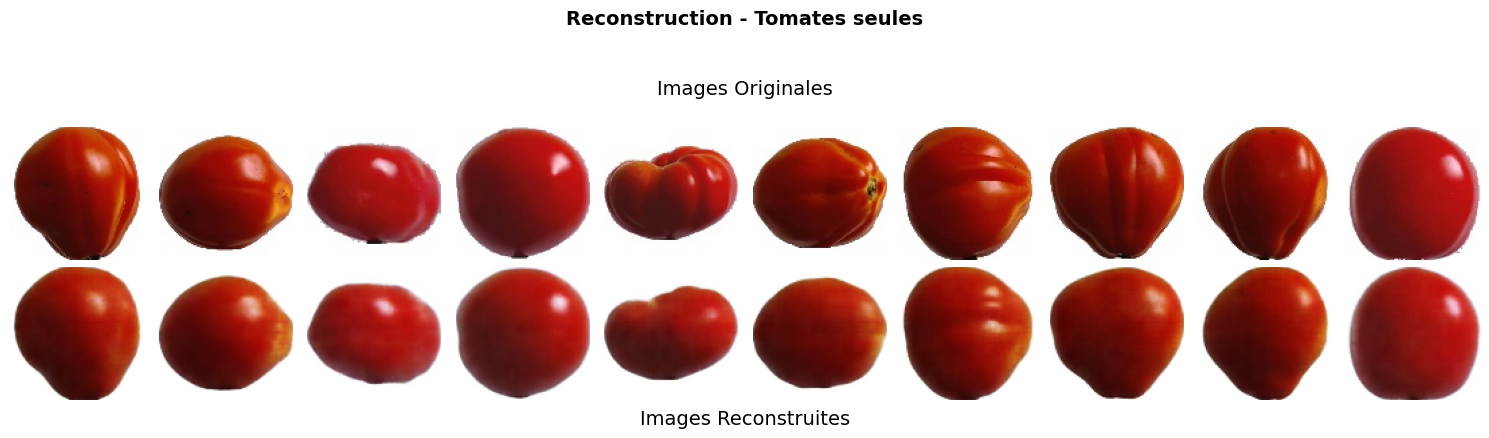

Found 4057 validated image filenames.


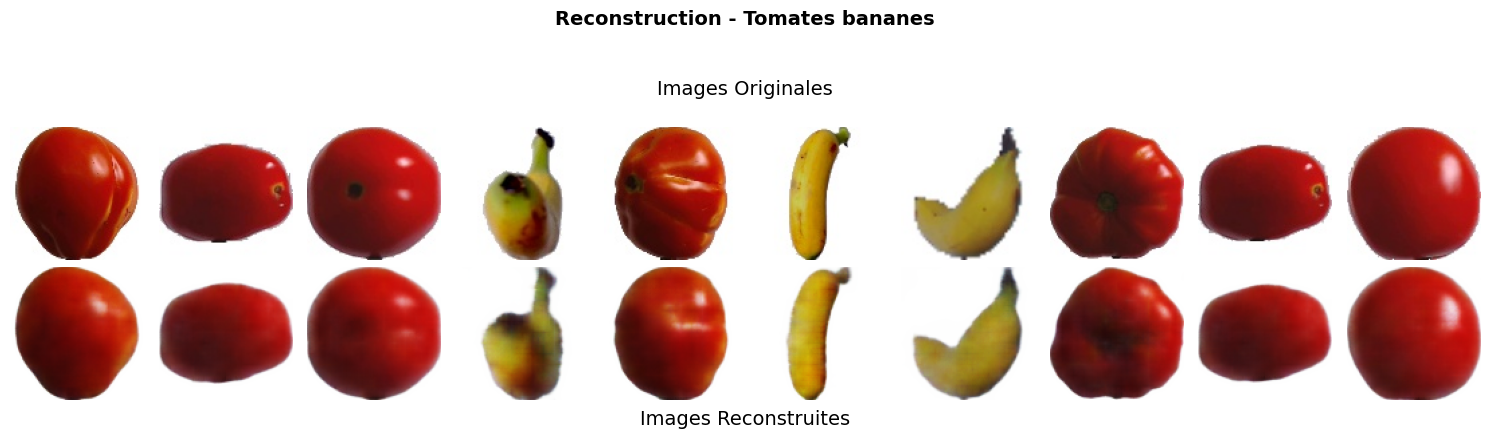

Found 5950 validated image filenames.


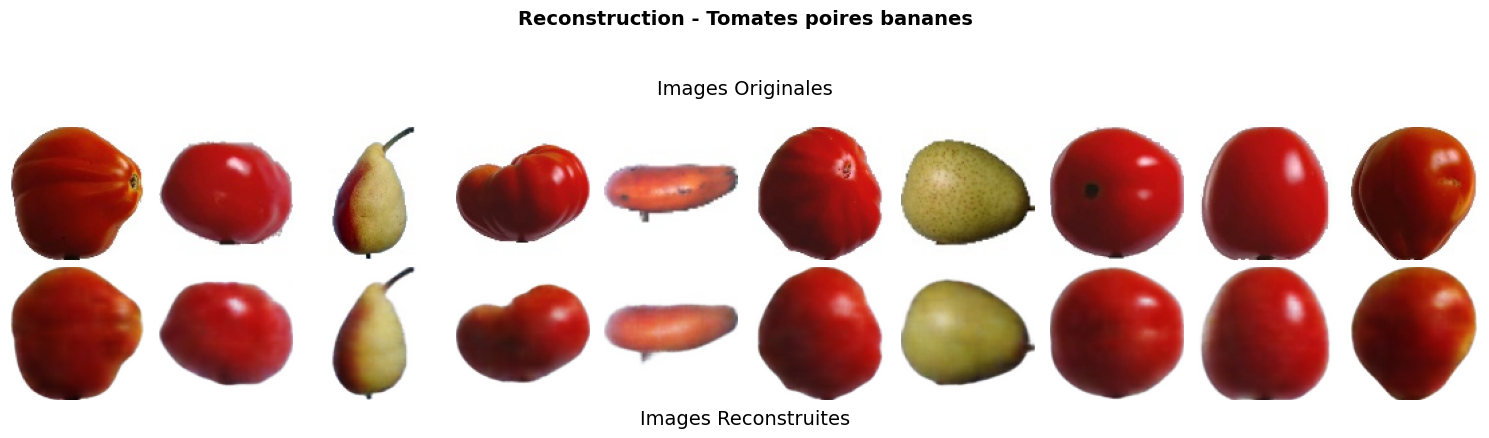

In [46]:
dataset_config = dataset_configs["tomates_seules"]
data_gen_tomates_seules = create_data_generator(
    dataset_dir=dataset_config["path"],
    allowed_labels=dataset_config["labels"],
    image_size=(image_height, image_width),
    batch_size=batch_size
)
plot_vae_reconstructions(vae_tomates_seules, data_gen_tomates_seules,
                         title="Reconstruction - Tomates seules")

dataset_config = dataset_configs["tomates_bananes"]
data_gen_tomates_bananes = create_data_generator(
    dataset_dir=dataset_config["path"],
    allowed_labels=dataset_config["labels"],
    image_size=(image_height, image_width),
    batch_size=batch_size
)
plot_vae_reconstructions(vae_tomates_bananes, data_gen_tomates_bananes,
                         title="Reconstruction - Tomates bananes")
dataset_config = dataset_configs["tomates_poires_bananes"]
data_gen_tomates_poires_bananes = create_data_generator(
    dataset_dir=dataset_config["path"],
    allowed_labels=dataset_config["labels"],
    image_size=(image_height, image_width),
    batch_size=batch_size
)
plot_vae_reconstructions(vae_tomates_poires_bananes,
                         data_gen_tomates_poires_bananes,
                         title="Reconstruction - Tomates poires bananes")

## latent - space

In [52]:
def plot_latent_space_with_density(
    vae_model,
    dataset_name,
    dataset_paths,
    model_dir,
    num_samples=500,
    grid_size=100,
    image_size=(28, 28),
    zoom=0.6,
    random_state=42
):
    """
    Affiche côte à côte :
    - à gauche : le t-SNE avec vignettes d'images
    - à droite : la densité estimée ("montagnes") dans l'espace latent

    Args:
        vae_model     : modèle VAE (avec la couche "vae_encoder_output")
        dataset_name  : nom du dataset (clé dans dataset_paths)
        dataset_paths : dict des chemins des datasets
        model_dir     : répertoire des fichiers .npz
        num_samples   : nombre d'images à utiliser
        grid_size     : résolution de la grille KDE
        image_size    : taille de chaque vignette (pixels)
        zoom          : facteur de zoom pour les vignettes
        random_state  : graine pour l'échantillonnage des images
    """
    dataset_dir = dataset_paths[dataset_name]["path"]
    label_file = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")

    data = np.load(label_file)
    filenames = data["filenames"]
    labels = data["labels"]

    rng = np.random.default_rng(random_state)
    unique_labels = np.unique(labels)
    target_size = min(num_samples, len(filenames))

    if target_size < len(unique_labels):
        selected_indices = rng.choice(len(filenames), size=target_size, replace=False)
    else:
        selected_parts = []
        base_quota = target_size // len(unique_labels)
        remainder = target_size % len(unique_labels)

        for label in unique_labels:
            label_indices = np.where(labels == label)[0]
            quota = min(base_quota, len(label_indices))
            if quota > 0:
                selected_parts.append(
                    rng.choice(label_indices, size=quota, replace=False)
                )

        selected_indices = np.concatenate(selected_parts) if selected_parts else np.array([], dtype=int)
        remaining_pool = np.setdiff1d(np.arange(len(filenames)), selected_indices, assume_unique=False)

        if remainder > 0 and len(remaining_pool) > 0:
            extra_size = min(remainder, len(remaining_pool))
            extra_indices = rng.choice(remaining_pool, size=extra_size, replace=False)
            selected_indices = np.concatenate([selected_indices, extra_indices])

        if len(selected_indices) < target_size:
            remaining_pool = np.setdiff1d(np.arange(len(filenames)), selected_indices, assume_unique=False)
            missing = min(target_size - len(selected_indices), len(remaining_pool))
            if missing > 0:
                extra_indices = rng.choice(remaining_pool, size=missing, replace=False)
                selected_indices = np.concatenate([selected_indices, extra_indices])

    selected_indices = rng.permutation(selected_indices)
    filenames = filenames[selected_indices]
    labels = labels[selected_indices]

    images = [
        np.array(Image.open(os.path.join(dataset_dir, f))) / 255.0
        for f in filenames
    ]
    x = np.stack(images)

    encoder_output = vae_model.get_layer("vae_encoder_output").output
    encoder = Model(inputs=vae_model.input, outputs=encoder_output)
    z = encoder.predict(x, verbose=0)
    z_tsne = TSNE(n_components=2, random_state=42).fit_transform(z)

    fig = plt.figure(figsize=(16, 7))

    # --- Subplot gauche : t-SNE avec vignettes ---
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.set_title(f"t-SNE avec vignettes — {dataset_name}", fontsize=14)

    for i, (x_tsne, y_tsne) in enumerate(z_tsne):
        thumb = array_to_img(x[i])
        thumb = thumb.resize(image_size)
        imagebox = OffsetImage(thumb, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x_tsne, y_tsne), frameon=False)
        ax1.add_artist(ab)

    ax1.set_xlim(z_tsne[:, 0].min() - 5, z_tsne[:, 0].max() + 5)
    ax1.set_ylim(z_tsne[:, 1].min() - 5, z_tsne[:, 1].max() + 5)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.grid(False)

    # --- Subplot droit : densité KDE 3D ---
    kde = gaussian_kde(z_tsne.T)
    x_vals = np.linspace(z_tsne[:, 0].min() - 5, z_tsne[:, 0].max() + 5,
                         grid_size)
    y_vals = np.linspace(z_tsne[:, 1].min() - 5, z_tsne[:, 1].max() + 5,
                         grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor='k', linewidth=0.1)
    ax2.set_title("Densité estimée dans l'espace latent", fontsize=14)
    ax2.set_xlabel("Latent dim 1")
    ax2.set_ylabel("Latent dim 2")
    ax2.set_zlabel("Densité")

    plt.tight_layout()
    plt.show()

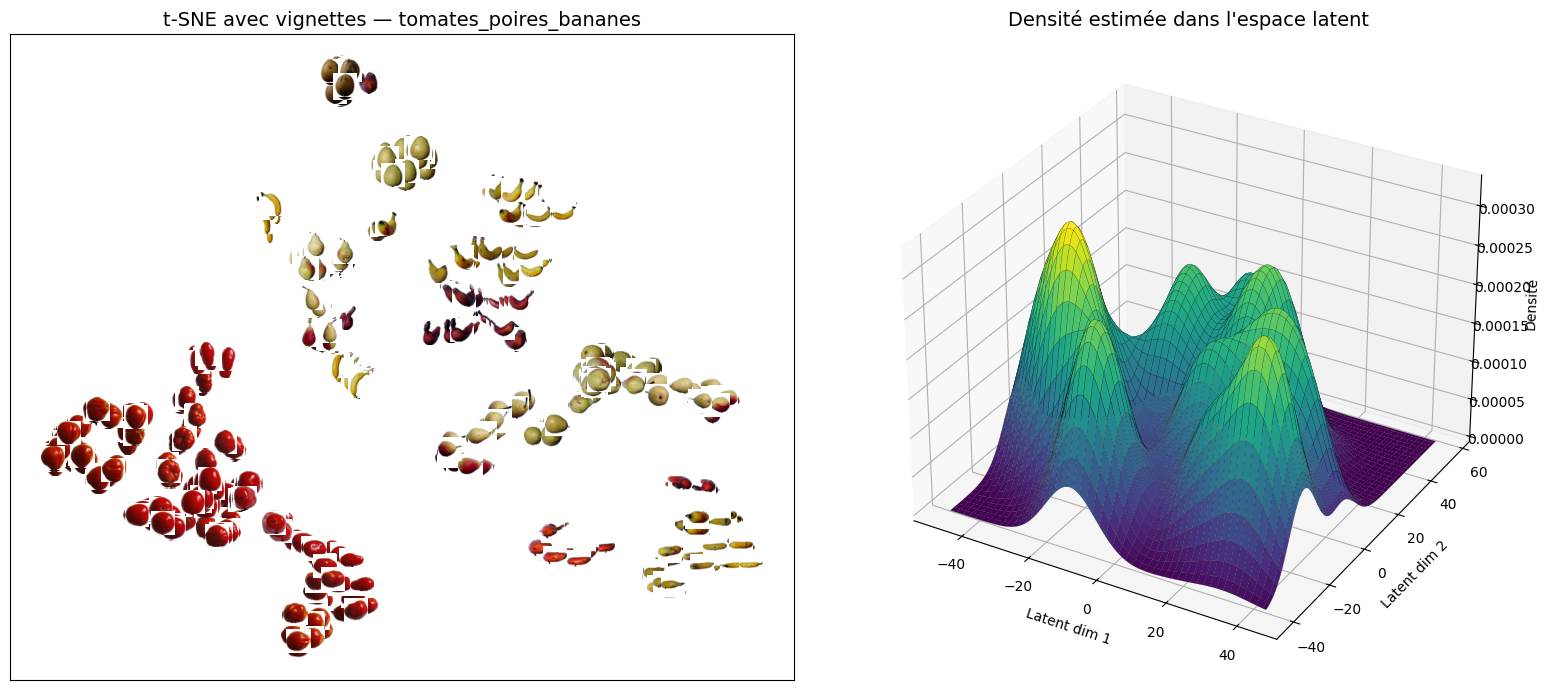

In [53]:
plot_latent_space_with_density(
    vae_model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    num_samples=1000
)

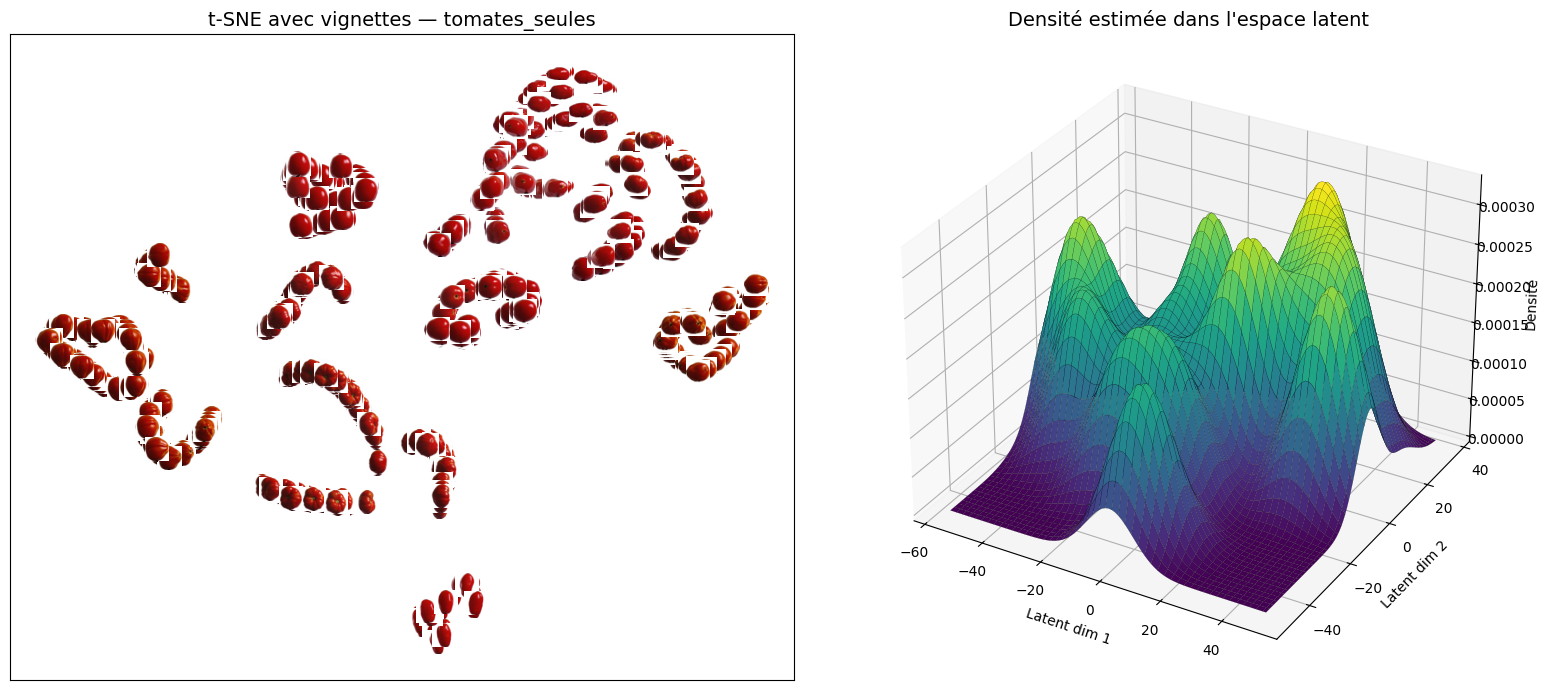

In [54]:
plot_latent_space_with_density(
    vae_model=vae_tomates_seules,
    dataset_name="tomates_seules",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    num_samples=1000
)

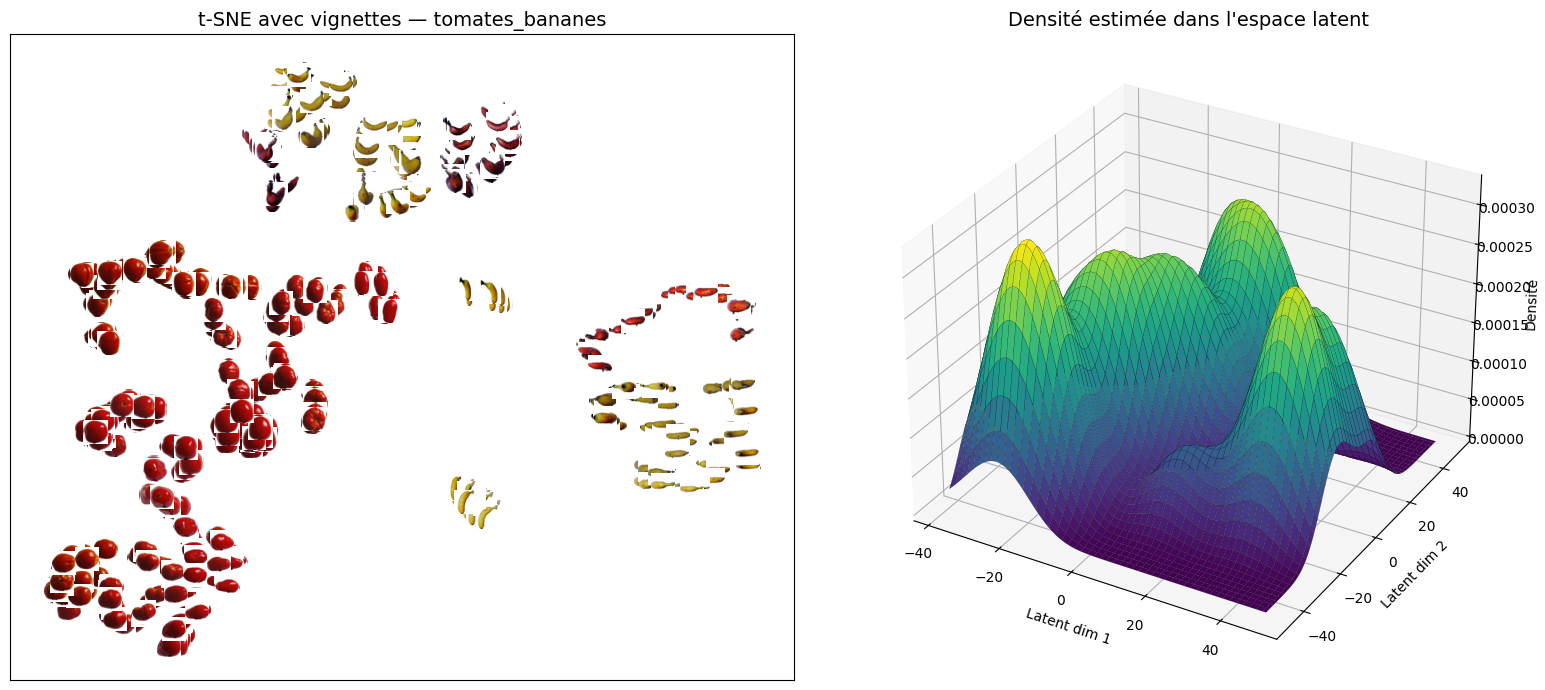

In [55]:
plot_latent_space_with_density(
    vae_model=vae_tomates_bananes,
    dataset_name="tomates_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    num_samples=1000
)

## histogramme vec latents

In [58]:
def plot_latent_histogram_from_vae(
    vae_model,
    dataset_name,
    dataset_paths,
    model_dir,
    title="Histogramme des vecteurs latents",
    dimensions=8,
    bins=50
):
    """
    Affiche un histogramme groupé des valeurs latentes pour chaque catégorie.

    Args:
        vae_model     : modèle VAE complet
        dataset_name  : nom du dataset dans dataset_paths
        dataset_paths : dict {nom: chemin}
        model_dir     : chemin vers les fichiers .npz
        title         : titre du graphique
        dimensions    : nombre de dimensions latentes à inclure (par défaut: 8)
        bins          : nombre de bins dans l'histogramme
    """
    label_map = {"t": "tomate", "p": "poire", "b": "banane"}

    dataset_dir = dataset_paths[dataset_name]["path"]
    label_file = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")
    data = np.load(label_file)
    filenames = data["filenames"]
    labels = data["labels"]

    images = [np.array(Image.open(os.path.join(dataset_dir, f))) / 255.0 for f in filenames]
    x = np.stack(images)

    encoder_output = vae_model.get_layer("vae_encoder_output").output
    encoder = Model(inputs=vae_model.input, outputs=encoder_output)
    latent_vectors = encoder.predict(x, verbose=0)

    dims_to_plot = range(min(dimensions, latent_vectors.shape[1]))

    data = []
    for label_code in np.unique(labels):
        idx = labels == label_code
        name = label_map.get(label_code, str(label_code))
        if np.sum(idx) > 1:
            class_values = latent_vectors[idx][:, dims_to_plot].flatten()
            data.extend([(v, name) for v in class_values])

    if not data:
      print("Pas de catégorie avec suffisamment de données pour l'histogramme.")
      return

    df = pd.DataFrame(data, columns=["Valeur latente", "Catégorie"])
    palette = sns.color_palette("Set2", len(df["Catégorie"].unique()))

    plt.figure(figsize=(12, 6))
    sns.histplot(
        data=df,
        x="Valeur latente",
        hue="Catégorie",
        bins=bins,
        kde=True,
        stat="density",
        element="step",
        palette=palette,
        alpha=0.6
    )
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Valeurs des vecteurs latents")
    plt.ylabel("Densité")
    plt.grid(alpha=0.3)
    plt.show()

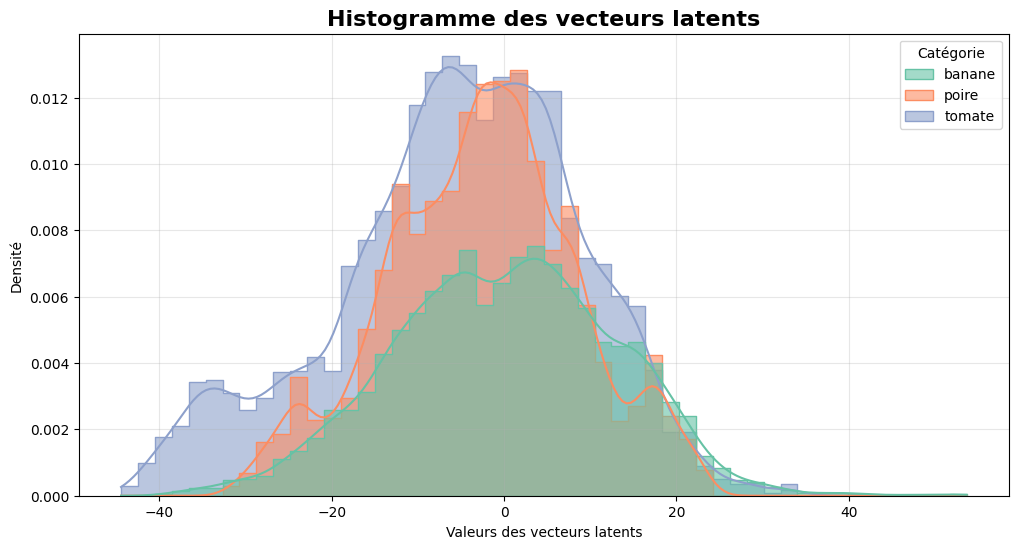

In [59]:
plot_latent_histogram_from_vae(
    vae_model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    dimensions=8
)

## distributions

In [62]:
def plot_latent_distribution_from_vae(
    vae_model,
    dataset_name,
    dataset_paths,
    model_dir,
    title="Distribution dans l'espace latent",
    dimensions=8
):
    """
    Visualise la distribution KDE des dimensions latentes par catégorie.

    Args:
        vae_model     : modèle VAE complet
        dataset_name  : nom du dataset dans dataset_paths
        dataset_paths : dict {nom: chemin}
        model_dir     : dossier contenant les fichiers .npz
        title         : titre du graphique
        dimensions    : nombre de dimensions latentes à tracer (commençant à 0)
    """
    label_map = {"t": "tomate", "p": "poire", "b": "banane"}

    dataset_dir = dataset_paths[dataset_name]["path"]
    label_file = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")
    data = np.load(label_file)
    filenames = data["filenames"]
    labels = data["labels"]

    images = [np.array(Image.open(os.path.join(dataset_dir, f))) / 255.0 for f in filenames]
    x = np.stack(images)

    encoder_output = vae_model.get_layer("vae_encoder_output").output
    encoder = Model(inputs=vae_model.input, outputs=encoder_output)
    latent_vectors = encoder.predict(x, verbose=0)

    num_latent_dims = latent_vectors.shape[1]
    dims_to_plot = range(min(dimensions, num_latent_dims))

    plt.figure(figsize=(14, 6))
    for i, dim in enumerate(dims_to_plot):
        plt.subplot(2, int(np.ceil(len(dims_to_plot) / 2)), i + 1)
        plotted = False
        for label_code in np.unique(labels):
            idx = labels == label_code
            class_data = latent_vectors[idx, dim]
            if len(class_data) > 1:
                name = label_map.get(label_code, str(label_code))
                sns.kdeplot(class_data, label=name, fill=True, alpha=0.5)
                plotted = True
        plt.title(f"Dimension {dim}")
        plt.xlabel("Valeur latente")
        plt.ylabel("Densité")
        if plotted:
            plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

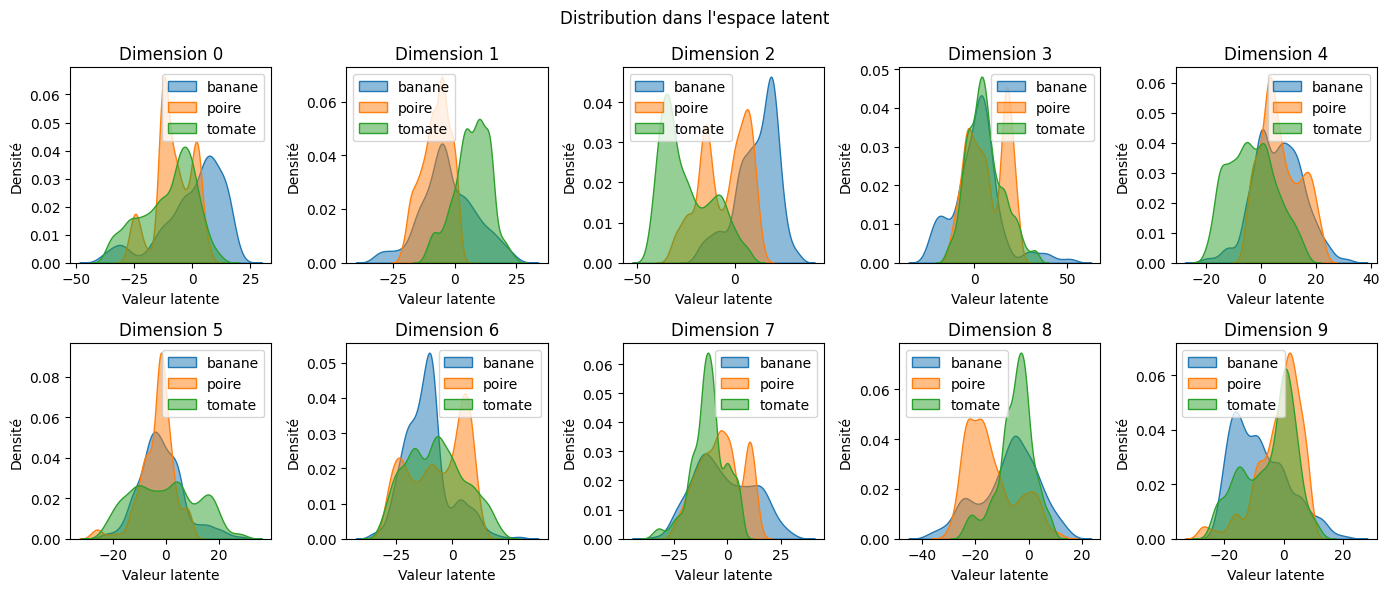

In [63]:
plot_latent_distribution_from_vae(
    vae_model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    dimensions=10
)

## Génération de données

### décodage aléatoire

In [64]:
def plot_random_latent_decodings(vae_model, latent_dim,
                                 n_images=10,
                                 title="Échantillons générés aléatoirement"):
    """
    Génère et affiche n_images décodées depuis des vecteurs latents tirés
    aléatoirement.

    Args:
        vae_model (tf.keras.Model): Modèle VAE complet (doit contenir un
        décodeur nommé "vae_decoder").
        latent_dim (int): Dimension de l'espace latent.
        n_images (int): Nombre d'images à générer.
        title (str): Titre du graphique.
    """
    decoder = vae_model.get_layer("vae_decoder")
    z_samples = np.random.normal(size=(n_images, latent_dim))
    decoded_images = decoder.predict(z_samples, verbose=0)

    plt.figure(figsize=(n_images * 1.5, 2))
    for i in range(n_images):
        ax = plt.subplot(1, n_images, i + 1)
        plt.imshow(np.clip(decoded_images[i], 0, 1))
        plt.axis("off")

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

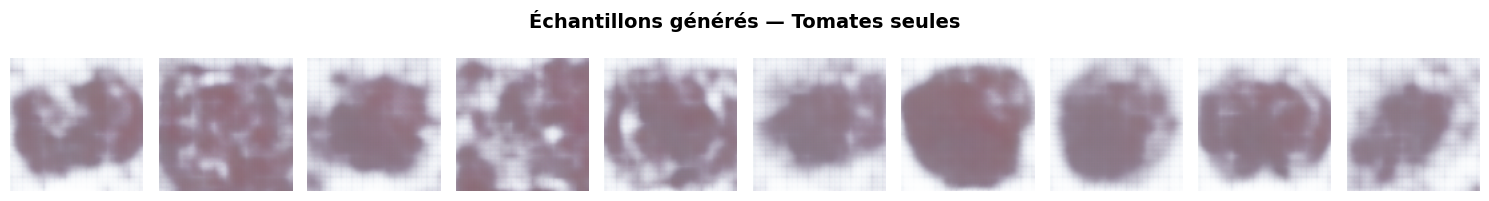

In [65]:
plot_random_latent_decodings(
    vae_model=vae_tomates_seules,
    latent_dim=latent_dim,
    n_images=10,
    title="Échantillons générés — Tomates seules"
)

### génération par classes

In [66]:
def generate_images_by_class_from_images(model, dataset_name,
                                         dataset_paths, model_dir,
                                         category_name, num_samples=10,
                                         noise_scale=0.1):
    """
    Génère et affiche des images depuis le VAE à partir d'images d'une classe
    donnée.

    Args:
        model : modèle VAE complet
        dataset_name : nom du dataset (clé dans dataset_paths)
        dataset_paths : dict contenant les chemins vers les datasets
        model_dir : dossier contenant le .npz des labels
        category_name : "tomate", "poire", "banane"
        num_samples : nombre d'images à générer
        noise_scale : écart-type du bruit latent
    """


    label_map = {"t": "tomate", "p": "poire", "b": "banane"}

    dataset_dir = dataset_paths[dataset_name]["path"]
    label_path = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")
    data = np.load(label_path)
    filenames = data["filenames"]
    labels = data["labels"]

    # Trouver le label associé à la classe demandée
    class_labels = []
    for f, lbl in zip(filenames, labels):
        fruit_code = os.path.basename(f)[0].lower()
        fruit_name = label_map.get(fruit_code)
        if fruit_name == category_name.lower():
            class_labels.append((f, lbl))

    if not class_labels:
        raise ValueError(f"Aucune image trouvée pour la classe '{category_name}' dans '{dataset_name}'.")

    selected_filenames, selected_labels = zip(*class_labels)
    images = [np.array(Image.open(os.path.join(dataset_dir, f))) / 255.0 for f in selected_filenames]
    x = np.stack(images)

    encoder_output = model.get_layer("vae_encoder_output").output
    encoder = Model(inputs=model.input, outputs=encoder_output)
    z_all = encoder.predict(x, verbose=0)

    decoder = model.get_layer("vae_decoder")

    plt.figure(figsize=(15, 2))
    for i in range(num_samples):
        idx = np.random.randint(len(z_all))
        noisy_z = z_all[idx] + np.random.normal(0, noise_scale,
                                                size=z_all.shape[1])
        decoded = decoder.predict(np.expand_dims(noisy_z, axis=0), verbose=0)[0]

        ax = plt.subplot(1, num_samples, i + 1)
        plt.imshow(np.clip(decoded, 0, 1))
        plt.axis("off")

    plt.suptitle(f"Génération aléatoire — {category_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

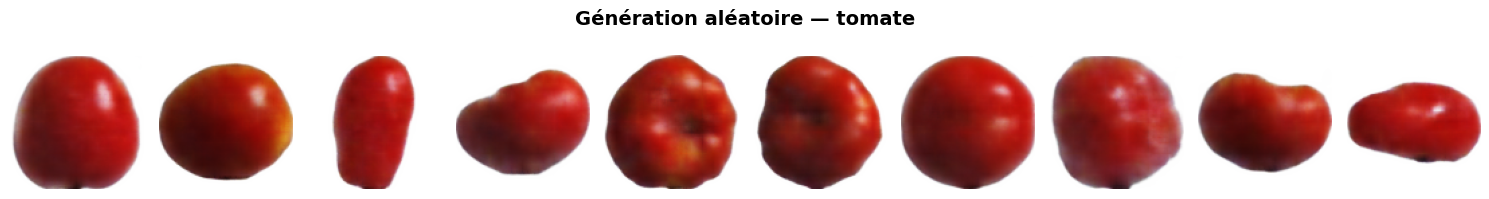

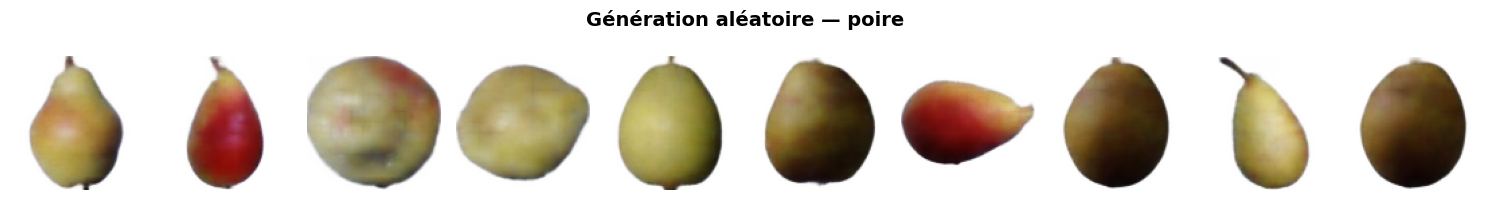

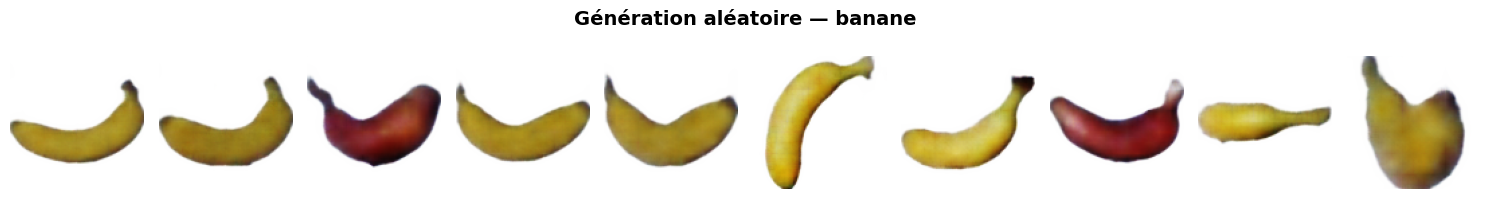

In [67]:
generate_images_by_class_from_images(
    model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    category_name="tomate",
    num_samples=10
)

generate_images_by_class_from_images(
    model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    category_name="poire",
    num_samples=10
)


generate_images_by_class_from_images(
    model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    category_name="banane",
    num_samples=10
)

### génération par apprentissage non supervisé

In [68]:
def generate_images_with_kmeans_from_images(
    model,
    dataset_name,
    dataset_paths,
    model_dir,
    num_samples=5,
    noise_scale=0.1,
    max_k=10
):
    """
    Applique KMeans à l'espace latent extrait depuis le VAE
    et génère des images à partir des centres des clusters.

    Returns:
        x : images d'entrée
        z : vecteurs latents
        cluster_labels : labels KMeans pour chaque image
        best_k : nombre optimal de clusters
        images_by_cluster : dictionnaire {cluster_id: [images générées]}
    """
    dataset_dir = dataset_paths[dataset_name]["path"]
    label_file = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")
    data = np.load(label_file)
    filenames = data["filenames"]

    images = [
        np.array(Image.open(os.path.join(dataset_dir, f))) / 255.0
        for f in filenames
    ]
    x = np.stack(images)

    # Encodeur
    encoder_output = model.get_layer("vae_encoder_output").output
    encoder = Model(inputs=model.input, outputs=encoder_output)
    z = encoder.predict(x, verbose=0)

    # KMeans et score silhouette
    silhouettes, ks = [], range(2, max_k + 1)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42).fit(z)
        silhouettes.append(silhouette_score(z, km.labels_))
    best_k = ks[np.argmax(silhouettes)]

    kmeans = KMeans(n_clusters=best_k, random_state=42).fit(z)
    cluster_labels = kmeans.labels_

    # Génération depuis les centres
    vae_decoder = model.get_layer("vae_decoder")
    images_by_cluster = {}
    for cluster_id, center in enumerate(kmeans.cluster_centers_):
        cluster_images = []
        for _ in range(num_samples):
            noisy_latent = center + np.random.normal(scale=noise_scale,
                                                     size=center.shape)
            decoded = vae_decoder.predict(np.expand_dims(noisy_latent,
                                                         axis=0), verbose=0)[0]
            cluster_images.append((decoded * 255).astype(np.uint8))
        images_by_cluster[cluster_id] = cluster_images

    return x, z, cluster_labels, best_k, images_by_cluster

def plot_tsne_image_thumbnails(x, z, best_k=None, image_size=(28, 28),
                               zoom=0.6, title="t-SNE avec vignettes d’images"):
    """
    Affiche les images originales en vignettes positionnées selon
    leur projection t-SNE de l’espace latent.

    Args:
        x (np.ndarray): Tableau des images originales.
        z (np.ndarray): Vecteurs latents correspondants.
        best_k (int, optional): Nombre de clusters optimal à
        afficher dans le titre.
        image_size (tuple): Dimensions de chaque vignette.
        zoom (float): Facteur de zoom sur les vignettes.
        title (str): Titre du plot.
    """
    if z.ndim > 2:
        z = z.reshape((z.shape[0], -1))

    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(z)

    fig, ax = plt.subplots(figsize=(15, 12))
    ax.set_title(f"{title} (k={best_k})" if best_k else title, fontsize=16, fontweight='bold')

    for i, (x_tsne, y_tsne) in enumerate(latent_2d):
        thumb = array_to_img(x[i])
        thumb = thumb.resize(image_size)
        imagebox = OffsetImage(thumb, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x_tsne, y_tsne), frameon=False)
        ax.add_artist(ab)

    ax.set_xlim(latent_2d[:, 0].min() - 5, latent_2d[:, 0].max() + 5)
    ax.set_ylim(latent_2d[:, 1].min() - 5, latent_2d[:, 1].max() + 5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    plt.tight_layout()
    plt.show()

def plot_images_by_cluster(images_by_cluster, images_per_row=5,
                           image_size=(2, 2), cmap=None):
    """
    Affiche les images générées par cluster avec un titre 'Cluster X'
    au-dessus de chaque ligne.

    Args:
        images_by_cluster (dict): Dictionnaire {cluster_id: [images]}.
        images_per_row (int): Nombre d’images par ligne.
        image_size (tuple): Taille individuelle de chaque image (w, h).
        cmap (str or None): Colormap à appliquer si images grayscale.
    """
    num_clusters = len(images_by_cluster)
    max_images = max(len(imgs) for imgs in images_by_cluster.values())
    images_per_row = min(images_per_row, max_images)

    fig, axs = plt.subplots(
        num_clusters, images_per_row,
        figsize=(images_per_row * image_size[0], num_clusters * image_size[1])
    )

    if num_clusters == 1:
        axs = [axs]  # force liste si 1 cluster

    for row, (cluster_id, images) in enumerate(images_by_cluster.items()):
        for col in range(images_per_row):
            ax = axs[row][col] if images_per_row > 1 else axs[row]
            if col < len(images):
                ax.imshow(images[col], cmap=cmap)
            ax.axis('off')

        # Ajouter le titre centré au-dessus de la ligne
        mid = images_per_row // 2
        ax_title = axs[row][mid] if images_per_row > 1 else axs[row]
        ax_title.set_title(f"Cluster {cluster_id}", fontsize=12, pad=20, weight="bold")

    plt.suptitle("Images générées par cluster", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

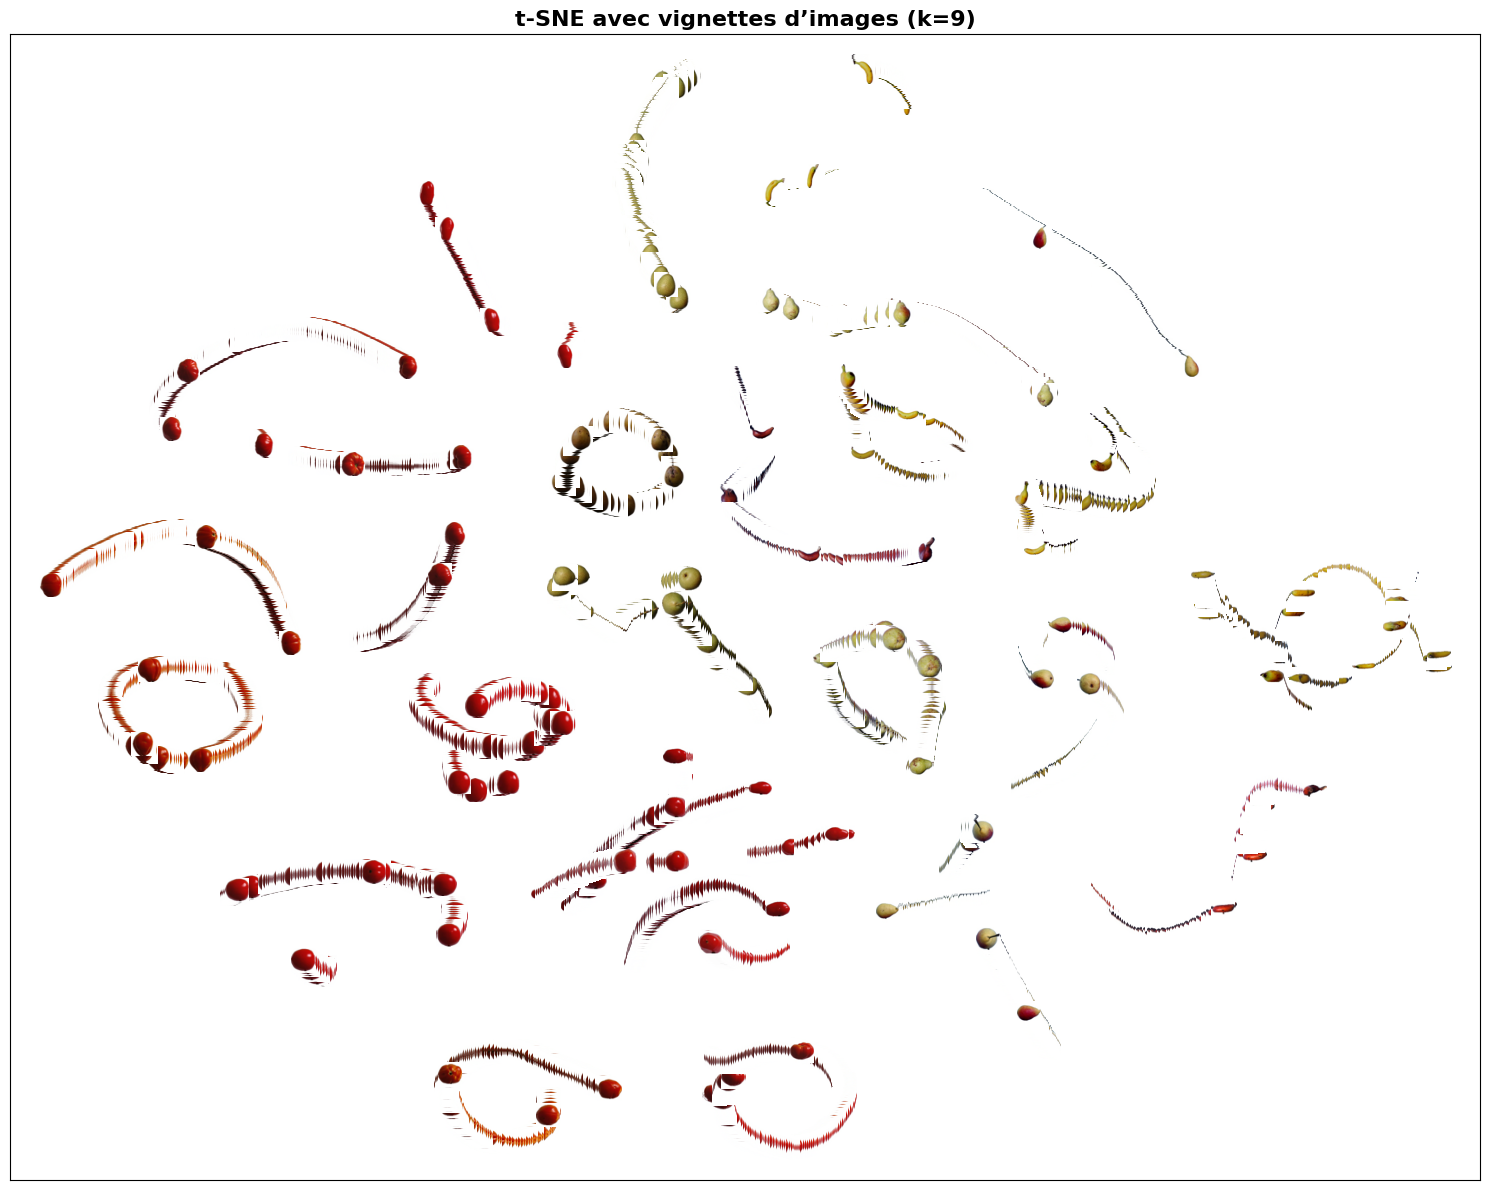

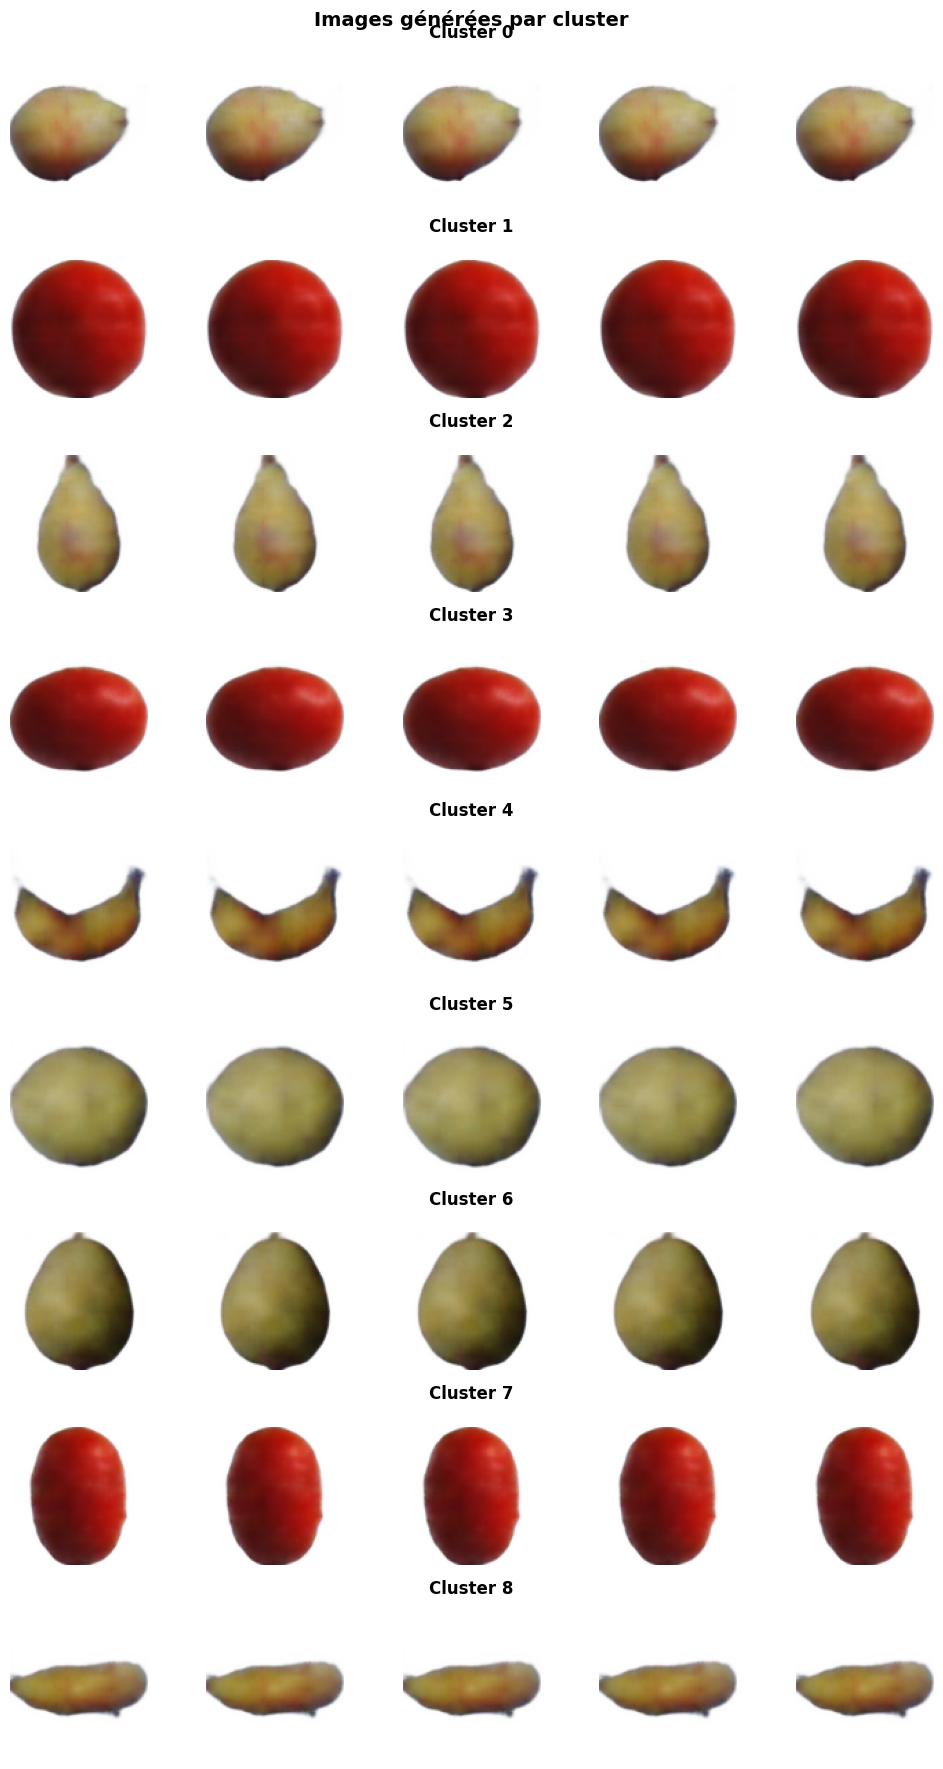

In [70]:
x, z, cluster_labels, best_k, images_by_cluster = generate_images_with_kmeans_from_images(
    model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    num_samples=5
)

plot_tsne_image_thumbnails(x, z, best_k=best_k)

plot_images_by_cluster(images_by_cluster)

### morphing (lerp inter-classes)

In [79]:
def generate_interpolated_images_from_images(
    model,
    dataset_name,
    dataset_paths,
    model_dir,
    class1,
    class2,
    num_steps=10,
    seed=None
):
    """
    Génère une interpolation entre deux images de classes différentes.


    Args:
        model        : VAE complet (contenant "vae_encoder_output" et
        "vae_decoder")
        dataset_name : nom du dataset
        dataset_paths: dictionnaire des chemins vers les datasets
        model_dir    : dossier contenant les fichiers .npz (filenames + labels)
        class1       : nom de la première classe (ex: "tomate")
        class2       : nom de la seconde classe (ex: "banane")
        num_steps    : nombre d'étapes d'interpolation
        seed         : graine optionnelle pour choisir de manière reproductible
        les images sources à interpoler

    Returns:
        interpolated_images : liste des images interpolées
    """
    label_map = {"t": "tomate", "p": "poire", "b": "banane"}
    dataset_dir = dataset_paths[dataset_name]["path"]
    rng = np.random.default_rng(seed) if seed is not None else None

    # Charger les fichiers et labels
    label_path = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")
    data = np.load(label_path)
    filenames = data["filenames"]

    def get_image_by_class(target_class):
        candidate_files = []
        for f in filenames:
            fruit_code = os.path.basename(f)[0].lower()
            fruit_name = label_map.get(fruit_code)
            if fruit_name == target_class.lower():
                candidate_files.append(f)

        if not candidate_files:
            raise ValueError(f"Aucune image pour la classe '{target_class}'.")

        if rng is None:
            selected_file = candidate_files[0]
        else:
            selected_file = candidate_files[rng.integers(len(candidate_files))]

        img = np.array(Image.open(os.path.join(dataset_dir, selected_file))) / 255.0
        return np.expand_dims(img, axis=0)

    # Encoder
    encoder = Model(inputs=model.input,
                    outputs=model.get_layer("vae_encoder_output").output)
    decoder = model.get_layer("vae_decoder")

    x1 = get_image_by_class(class1)
    x2 = get_image_by_class(class2)

    z1 = encoder.predict(x1, verbose=0)[0]
    z2 = encoder.predict(x2, verbose=0)[0]

    interpolated_images = []
    for alpha in np.linspace(0, 1, num_steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        x_gen = decoder.predict(np.expand_dims(z_interp, axis=0), verbose=0)[0]
        interpolated_images.append(np.clip(x_gen * 255, 0, 255).astype(np.uint8))

    return interpolated_images

In [72]:
def display_generated_images(images, category_name="", figsize=(15, 2),
                             cmap=None):
    """
    Affiche les images générées côte à côte avec un titre.

    Args:
        images (list[np.ndarray]): Liste d'images à afficher.
        category_name (str): Titre à afficher au-dessus des images.
        figsize (tuple): Taille de la figure matplotlib.
        cmap (str or None): Colormap à appliquer si les images sont en niveaux
        de gris.
    """
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=figsize, squeeze=False)
    fig.suptitle(category_name, fontsize=16, fontweight='bold')

    for i, img in enumerate(images):
        ax = axes[0, i]
        ax.imshow(img, cmap=cmap)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

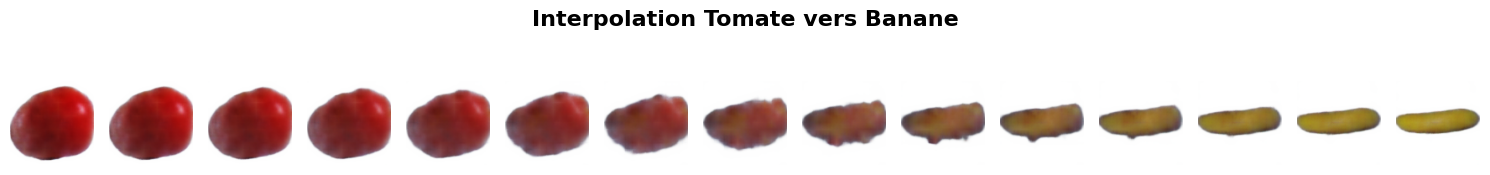

In [95]:
interpolated_images = generate_interpolated_images_from_images(
    model=vae_tomates_bananes,
    dataset_name="tomates_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    class1="tomate",
    class2="banane",
    num_steps=15,
    seed=324
)

display_generated_images(interpolated_images,
                         category_name="Interpolation Tomate vers Banane")

In [80]:
def generate_interpolated_images_n_classes(
    model,
    dataset_name,
    dataset_paths,
    model_dir,
    class_names,
    num_steps=10,
    seed=None
):
    """
    Génère des images en interpolant entre plusieurs classes successives dans
    l’espace latent.


    Args:
        model         : VAE complet avec encodeur et décodeur.
        dataset_name  : nom du dataset (clé dans dataset_paths).
        dataset_paths : dict contenant les chemins vers les datasets.
        model_dir     : répertoire contenant les fichiers .npz.
        class_names   : liste des noms de classes (ex : ["tomate", "banane",
        "poire"]).
        num_steps     : nombre d’images interpolées entre chaque paire de
        classes.
        seed          : graine optionnelle pour choisir de manière reproductible
        une image par classe

    Returns:
        interpolated_images : liste d’images générées (np.ndarray).
    """
    label_map = {"t": "tomate", "p": "poire", "b": "banane"}
    dataset_dir = dataset_paths[dataset_name]["path"]
    label_path = os.path.join(model_dir, f"{dataset_name}_image_labels.npz")
    rng = np.random.default_rng(seed) if seed is not None else None

    data = np.load(label_path)
    filenames = data["filenames"]
    labels = data["labels"]

    encoder_output = model.get_layer("vae_encoder_output").output
    encoder = Model(inputs=model.input, outputs=encoder_output)

    def get_latent_vector_for_class(target_class_name):
        candidate_files = []
        for f, lbl in zip(filenames, labels):
            fruit_code = os.path.basename(f)[0].lower()
            fruit_name = label_map.get(fruit_code)
            if fruit_name == target_class_name.lower():
                candidate_files.append(f)

        if not candidate_files:
            raise ValueError(f"Aucune image pour la classe '{target_class_name}'.")

        if rng is None:
            selected_file = candidate_files[0]
        else:
            selected_file = candidate_files[rng.integers(len(candidate_files))]

        img = np.array(Image.open(os.path.join(dataset_dir, selected_file))) / 255.0
        x = np.expand_dims(img, axis=0)
        return encoder.predict(x, verbose=0)[0]

    latents = [get_latent_vector_for_class(cls) for cls in class_names]
    decoder = model.get_layer("vae_decoder")
    interpolated_images = []

    for i in range(len(latents) - 1):
        z1, z2 = latents[i], latents[i + 1]
        for alpha in np.linspace(0, 1, num_steps):
            z_interp = (1 - alpha) * z1 + alpha * z2
            decoded = decoder.predict(np.expand_dims(z_interp, axis=0),
                                      verbose=0)[0]
            interpolated_images.append((decoded * 255).astype(np.uint8))

    return interpolated_images

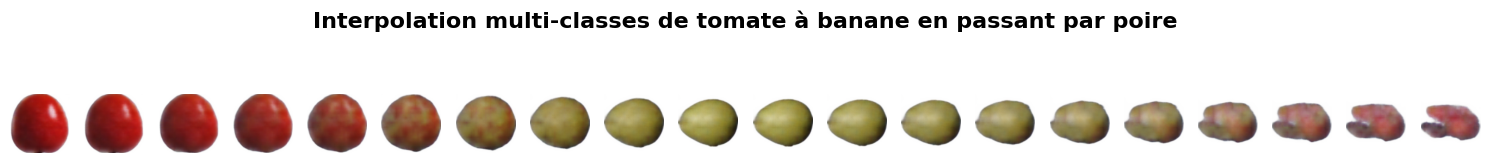

In [85]:
interpolated = generate_interpolated_images_n_classes(
    model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    class_names=["tomate", "poire" , "banane"],
    num_steps=10,
    seed=32
)

display_generated_images(interpolated,
                         category_name="Interpolation multi-classes de tomate à banane en passant par poire")

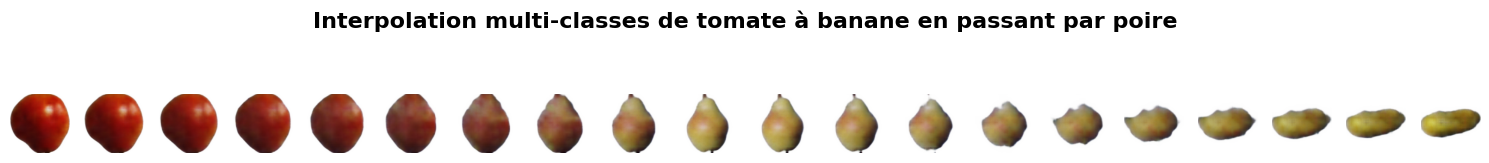

In [86]:
interpolated = generate_interpolated_images_n_classes(
    model=vae_tomates_poires_bananes,
    dataset_name="tomates_poires_bananes",
    dataset_paths=dataset_configs,
    model_dir=model_dir,
    class_names=["tomate", "poire" , "banane"],
    num_steps=10,
    seed=42
)

display_generated_images(interpolated,
                         category_name="Interpolation multi-classes de tomate à banane en passant par poire")